# Lorenz 63

The Lorenz 63 system is a 3-dimensional ODE,

$$
\begin{aligned}
\dot{x}_1 &= \sigma (x_2 - x_1), \\
\dot{x}_2 &= x_1 (\rho - x_3) - x_2, \\
\dot{x}_3 &= x_1 x_2 - \beta x_3,
\end{aligned}
$$

with $\sigma = 10$, $\beta = 8/3$ and $\rho = 28$, which generates chaotic behaviors. The ground truth is numerically integrated with the 4th-order Runge-Kutta (RK4) method with a time step of $h = 0.01$ s, and the learned models are rolled out autoregressively at the same sampling time step.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'eval':
    os.chdir('..')
sys.path[:0] = ['src', 'eval']
import numpy as np
import torch
from PIL import Image
from eval_L63 import load_lorenz63_model, generate_test_traj, plot_attractor_projections, plot_flow_map, plot_V_history

def show(*names, height=420):
    for name in names:
        im = Image.open(os.path.join(out_dir, name))
        display(im.resize((round(im.width * height / im.height), height)))

Set up output directory and load model checkpoint

In [2]:
out_dir = 'figures/lorenz63'
os.makedirs(out_dir, exist_ok=True)
np.random.seed(0)
torch.manual_seed(0)
model, params = load_lorenz63_model('assets/models/lorenz63/proj', 'E29999.pt', proj_flag=True, discrete_dt=0.01, discrete_h=0.01)
print(f'c = {model.c.item()**2:.2f}')  # Note: model.c stores the square root of the paper's c

c = 781.91


Generate rollout trajectories using the learned model checkpoint

In [3]:
X_GT, X_star = generate_test_traj(model, Test_N=50000, Test_M=1, dt=0.01, Test_xlim=50.0, params=params)

Generating ground-truth trajectories


  0%|          | 0/49999 [00:00<?, ?it/s]

100%|██████████| 49999/49999 [00:14<00:00, 3541.34it/s]


Rolling out the learned model


100%|██████████| 49999/49999 [01:04<00:00, 781.11it/s]


Reproducing Figure 3 in the paper

Saved Fig 3A to figures/lorenz63/Ellip_views.png
Saved Fig 3B to figures/lorenz63/flow_map_projection.png


100%|██████████| 50000/50000 [00:05<00:00, 8680.80it/s]


Saved Fig 3C to figures/lorenz63/V_test.png


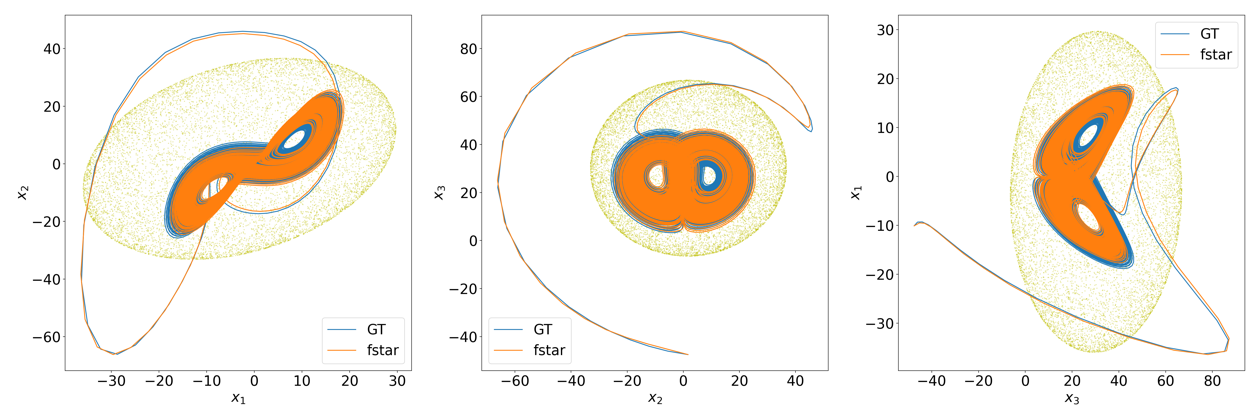

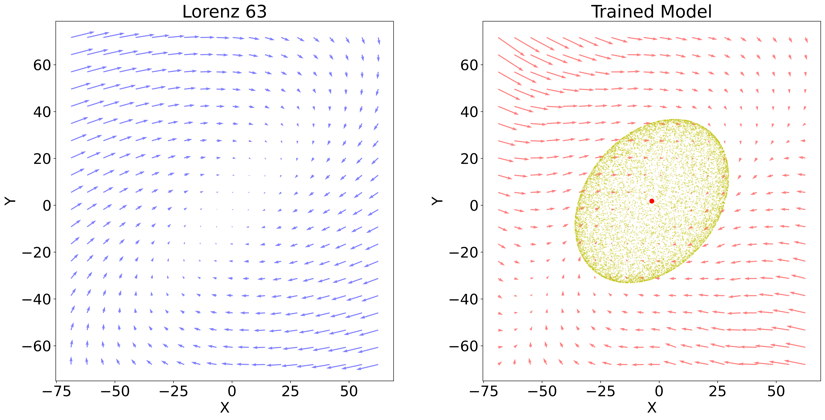

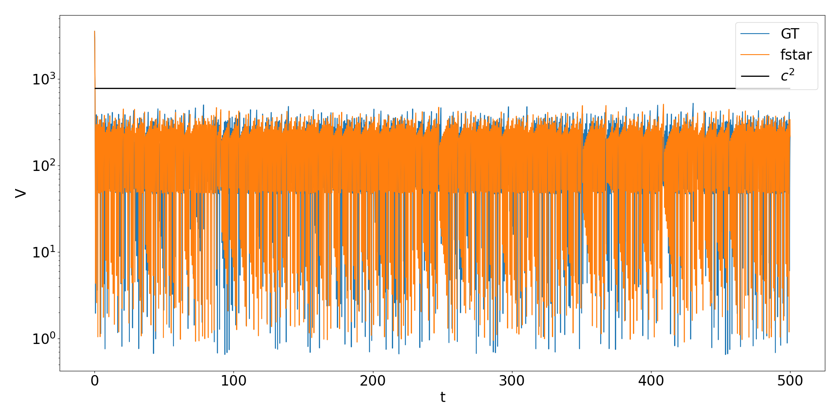

In [4]:
plot_attractor_projections(X_GT, X_star, model, params, out_dir)
plot_flow_map(model, params, out_dir)
plot_V_history(X_GT, X_star, model, params, out_dir)
show('Ellip_views.png', 'flow_map_projection.png', 'V_test.png')